# Phase 3 – Probability & Inferential Statistics

## Objective

The objective of this notebook is to apply probability concepts and inferential statistical methods to the processed Hotel Booking Demand dataset. This analysis provides a statistical foundation for assumption testing and hypothesis testing in the subsequent phases.

## Import Libraries

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from scipy.stats import norm

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Dataset

In [9]:
dataset_path = "../data/processed/final_hotel_bookings.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Dataset Information

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87225 entries, 0 to 87224
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87225 non-null  str    
 1   is_canceled                     87225 non-null  bool   
 2   lead_time                       87225 non-null  int64  
 3   arrival_date_year               87225 non-null  int64  
 4   arrival_date_month              87225 non-null  str    
 5   arrival_date_week_number        87225 non-null  int64  
 6   arrival_date_day_of_month       87225 non-null  int64  
 7   stays_in_weekend_nights         87225 non-null  int64  
 8   stays_in_week_nights            87225 non-null  float64
 9   adults                          87225 non-null  int64  
 10  children                        87225 non-null  float64
 11  babies                          87225 non-null  int64  
 12  meal                            87225 non-n

## Dataset Shape

In [11]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 87225
Columns : 39


## First Five Records

In [12]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,hotel_label,total_stay_duration,total_guests,lead_time_category,stay_type,booking_season,guest_status
0,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,0.0,2.0,Very Long,Weekday,Summer,New
1,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,0.0,2.0,Very Long,Weekday,Summer,New
2,Resort Hotel,False,7,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,2.0,Short,Weekday,Summer,New
3,Resort Hotel,False,13,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,2.0,Short,Weekday,Summer,New
4,Resort Hotel,False,14,2015,July,27,1,0,2.0,2,0.0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,1,2.0,2.0,Short,Weekday,Summer,New


## Numerical Columns

In [13]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_columns)

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'company', 'days_in_waiting_list',
       'average_daily_rate', 'required_car_parking_spaces',
       'total_of_special_requests', 'hotel_label', 'total_stay_duration',
       'total_guests'],
      dtype='str')


## Descriptive Statistics

In [14]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87225.0,78.444918,81.052481,0.0,11.00,49.0,125.0,296.000
arrival_date_year,87225.0,2016.210398,0.686029,2015.0,2016.00,2016.0,2017.0,2017.000
arrival_date_week_number,87225.0,26.835036,13.669439,1.0,16.00,27.0,37.0,53.000
arrival_date_day_of_month,87225.0,15.816383,8.835459,1.0,8.00,16.0,23.0,31.000
stays_in_weekend_nights,87225.0,0.998899,0.993097,0.0,0.00,1.0,2.0,5.000
stays_in_week_nights,87225.0,2.577048,1.804803,0.0,1.00,2.0,4.0,8.500
adults,87225.0,2.000000,0.000000,2.0,2.00,2.0,2.0,2.000
children,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000
babies,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000
previous_cancellations,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000


## Conclusion

#### The processed dataset was successfully loaded and inspected. Numerical variables relevant to statistical analysis were identified, and descriptive statistics confirmed that the dataset is ready for probability and inferential statistical analysis.

# Probability & Inferential Statistics

## Probability Distribution

### Select the Variable

In [15]:
adr = df["average_daily_rate"]

### Calculate Basic Statistics

In [16]:
mean_adr = adr.mean()
median_adr = adr.median()
mode_adr = adr.mode()[0]
variance_adr = adr.var()
std_adr = adr.std()

summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Variance",
        "Standard Deviation"
    ],
    "Value": [
        mean_adr,
        median_adr,
        mode_adr,
        variance_adr,
        std_adr
    ]
})

summary

,Statistic,Value
0,Mean,105.524569
1,Median,98.200000
2,Mode,226.875000
3,Variance,2404.227561
4,Standard Deviation,49.032923


### Print the Values

In [17]:
print(f"Mean               : {mean_adr:.2f}")
print(f"Median             : {median_adr:.2f}")
print(f"Mode               : {mode_adr:.2f}")
print(f"Variance           : {variance_adr:.2f}")
print(f"Standard Deviation : {std_adr:.2f}")

Mean               : 105.52
Median             : 98.20
Mode               : 226.88
Variance           : 2404.23
Standard Deviation : 49.03


### Histogram with KDE

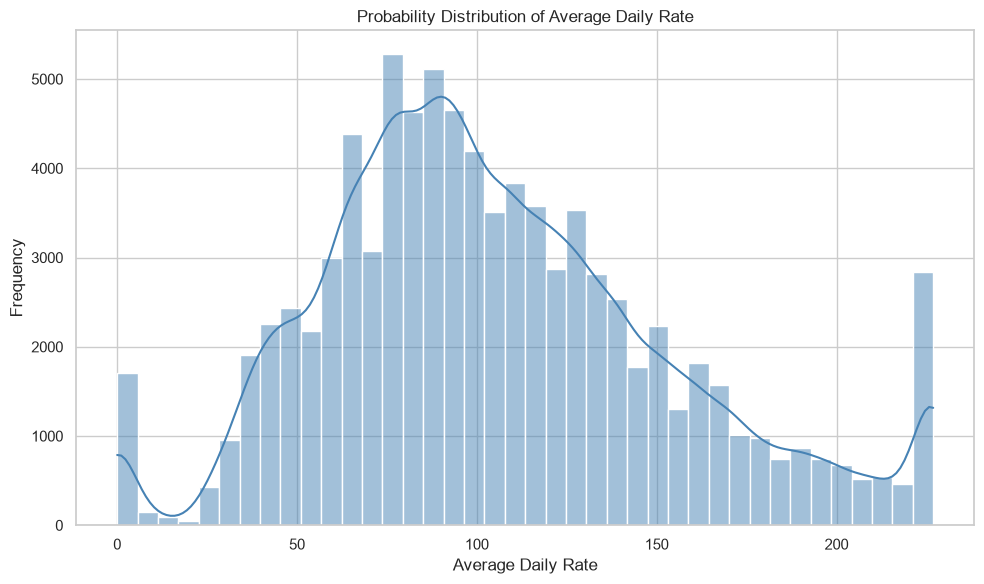

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    adr,
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Probability Distribution of Average Daily Rate")

plt.xlabel("Average Daily Rate")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/adr_probability_distribution.png",
    dpi=300
)

plt.show()

### Normal Distribution Curve

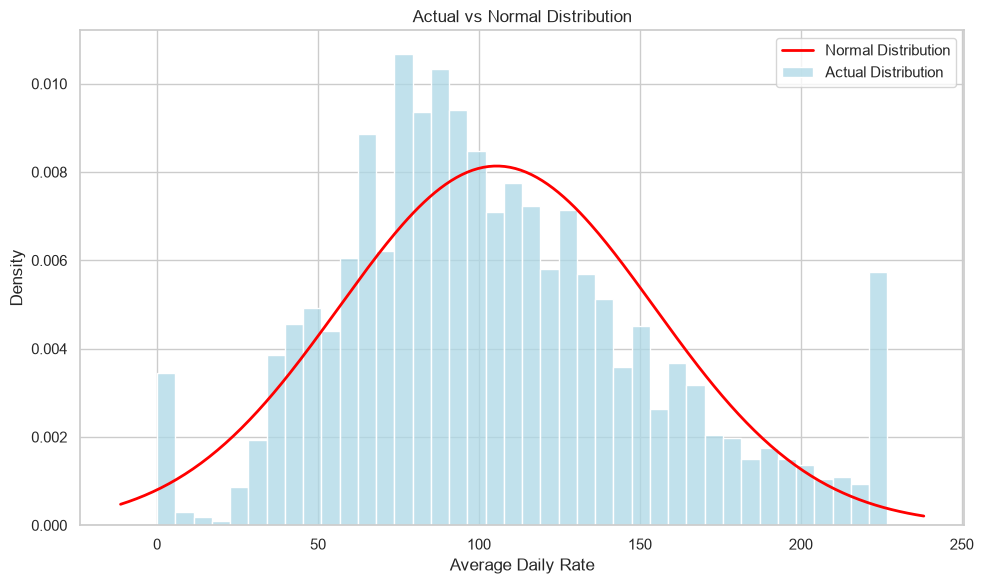

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(
    adr,
    bins=40,
    stat="density",
    color="lightblue",
    label="Actual Distribution"
)

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 300)

y = norm.pdf(
    x,
    mean_adr,
    std_adr
)

plt.plot(
    x,
    y,
    color="red",
    linewidth=2,
    label="Normal Distribution"
)

plt.title("Actual vs Normal Distribution")

plt.xlabel("Average Daily Rate")

plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/adr_normal_distribution.png",
    dpi=300
)

plt.show()

### Box Plot

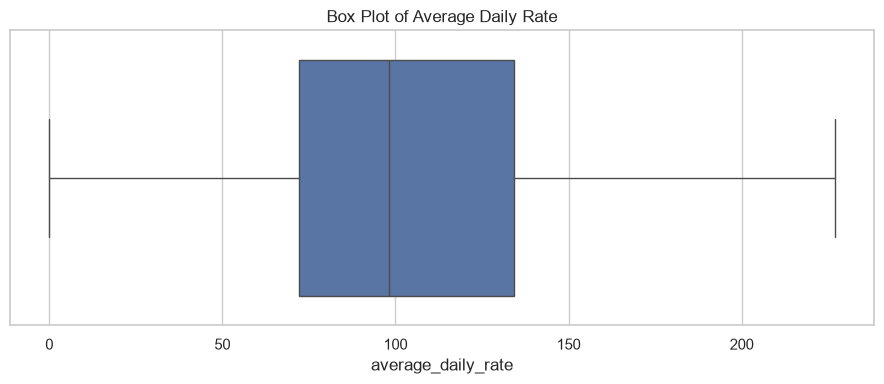

In [21]:
plt.figure(figsize=(9,4))

sns.boxplot(
    x=adr
)

plt.title("Box Plot of Average Daily Rate")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/adr_boxplot.png",
    dpi=300
)

plt.show()

### Distribution Summary Table

In [22]:
distribution_summary = pd.DataFrame({
    "Measure": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Variance",
        "Standard Deviation"
    ],
    "Value": [
        adr.min(),
        adr.max(),
        mean_adr,
        median_adr,
        variance_adr,
        std_adr
    ]
})

distribution_summary

,Measure,Value
0,Minimum,0.000000
1,Maximum,226.875000
2,Mean,105.524569
3,Median,98.200000
4,Variance,2404.227561
5,Standard Deviation,49.032923


## Business Interpretation

### The Average Daily Rate (ADR) represents the average revenue earned per occupied room per day. The histogram and density curve indicate how room prices are distributed across bookings. Comparing the observed distribution with a theoretical normal distribution helps assess whether ADR is approximately normal or skewed. This understanding is important because many statistical methods applied in later phases assume normality. The box plot also highlights the spread of ADR values and any potential outliers that may influence statistical analysis.

### Probability Density Example

In [23]:
lower = mean_adr - std_adr
upper = mean_adr + std_adr

within_one_std = (
    (adr >= lower) &
    (adr <= upper)
).mean()

print(f"Probability within one standard deviation: {within_one_std:.4f}")
print(f"Percentage: {within_one_std * 100:.2f}%")

Probability within one standard deviation: 0.7041
Percentage: 70.41%


## Conclusion

#### The probability distribution of the Average Daily Rate (ADR) was analyzed using descriptive statistics, histograms, density curves, and box plots. The observed distribution was compared with a theoretical normal distribution to evaluate its shape and variability. The probability of observations falling within one standard deviation of the mean was also calculated, providing a practical illustration of probability concepts and a foundation for the assumption testing and inferential analyses in later phases.

# Conditional Probability

### Overall Cancellation Probability

In [24]:
overall_cancel_prob = df["is_canceled"].mean()

print(f"Overall Cancellation Probability : {overall_cancel_prob:.4f}")
print(f"Percentage : {overall_cancel_prob*100:.2f}%")

Overall Cancellation Probability : 0.2752
Percentage : 27.52%


### Conditional Probability (Hotel Type)

In [25]:
city_cancel_probability = (
    df.loc[df["hotel"] == "City Hotel", "is_canceled"]
      .mean()
)

print(
    f"P(Cancelled | City Hotel) = {city_cancel_probability:.4f}"
)

P(Cancelled | City Hotel) = 0.3009


In [26]:
# Probability of cancellation given Resort Hotel.

resort_cancel_probability = (
    df.loc[df["hotel"] == "Resort Hotel", "is_canceled"]
      .mean()
)

print(
    f"P(Cancelled | Resort Hotel) = {resort_cancel_probability:.4f}"
    )

P(Cancelled | Resort Hotel) = 0.2348


### Comparison Table

In [27]:
hotel_probability = pd.DataFrame({

    "Hotel Type":[
        "City Hotel",
        "Resort Hotel"
    ],

    "Cancellation Probability":[
        city_cancel_probability,
        resort_cancel_probability
    ]

})

hotel_probability

,Hotel Type,Cancellation Probability
0,City Hotel,0.300939
1,Resort Hotel,0.234840


### Visualization

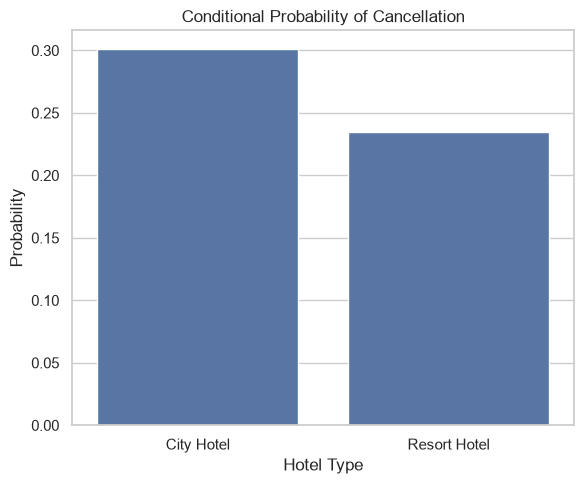

In [28]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=hotel_probability,
    x="Hotel Type",
    y="Cancellation Probability"
)

plt.title("Conditional Probability of Cancellation")

plt.ylabel("Probability")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/cancellation_probability_hotel.png",
    dpi=300
)

plt.show()

### Conditional Probability by Customer Type

In [29]:
customer_probability = (
    df.groupby("customer_type")["is_canceled"]
      .mean()
      .reset_index()
)

customer_probability.rename(
    columns={
        "is_canceled":"Cancellation Probability"
    },
    inplace=True
)

customer_probability

,customer_type,Cancellation Probability
0,Contract,0.163317
1,Group,0.097967
2,Transient,0.301425
3,Transient-Party,0.152220


### Visualization

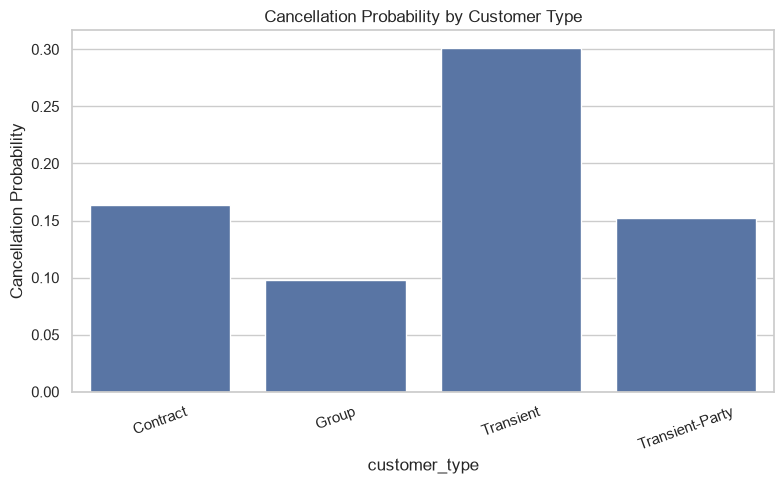

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_probability,
    x="customer_type",
    y="Cancellation Probability"
)

plt.xticks(rotation=20)

plt.title(
    "Cancellation Probability by Customer Type"
)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/customer_probability.png",
    dpi=300
)

plt.show()

### Conditional Probability by Booking Season

In [31]:
season_probability = (
    df.groupby("booking_season")["is_canceled"]
      .mean()
      .reset_index()
)

season_probability.rename(
    columns={
        "is_canceled":"Cancellation Probability"
    },
    inplace=True
)

season_probability

,booking_season,Cancellation Probability
0,Autumn,0.233366
1,Spring,0.281350
2,Summer,0.315701
3,Winter,0.240932


### Visualization

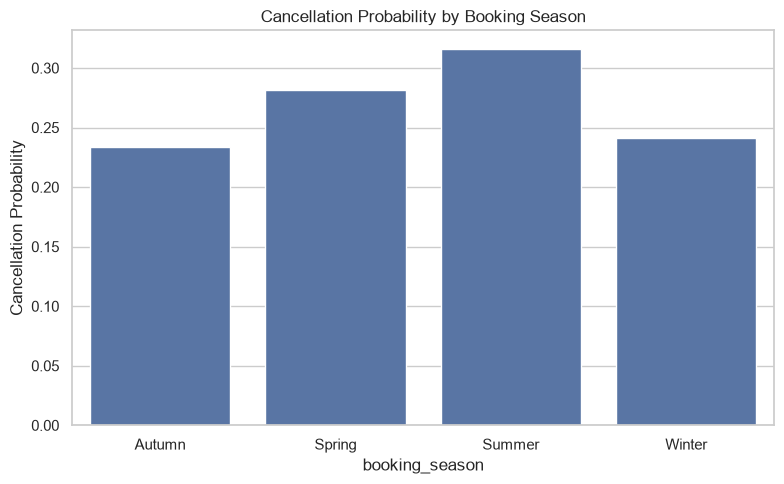

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=season_probability,
    x="booking_season",
    y="Cancellation Probability"
)

plt.title(
    "Cancellation Probability by Booking Season"
)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/season_probability.png",
    dpi=300
)

plt.show()

### Probability Matrix

In [33]:
probability_matrix = pd.crosstab(

    df["hotel"],
    df["is_canceled"],

    normalize="index"

)

probability_matrix.columns = [
    "Not Cancelled",
    "Cancelled"
]

probability_matrix

,Not Cancelled,Cancelled
hotel,,
City Hotel,0.699061,0.300939
Resort Hotel,0.765160,0.234840


## Heatmap

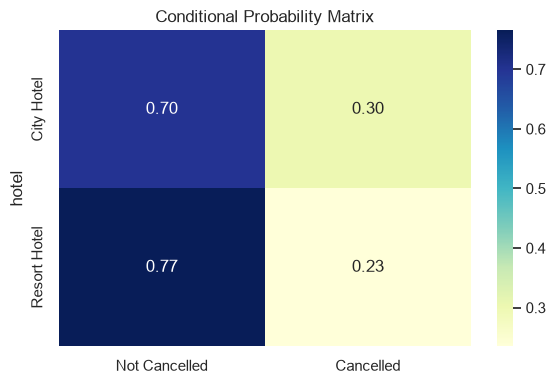

In [34]:
plt.figure(figsize=(6,4))

sns.heatmap(

    probability_matrix,

    annot=True,

    cmap="YlGnBu",

    fmt=".2f"

)

plt.title(
    "Conditional Probability Matrix"
)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/probability_matrix.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Conditional probability provides a more meaningful measure than overall probability because it evaluates cancellation behavior within specific groups. The analysis reveals how cancellation likelihood changes based on hotel type, customer type, and booking season. These insights help hotel managers identify higher-risk booking segments and develop targeted strategies such as flexible pricing, promotional offers, or adjusted cancellation policies.

## Conclusion

#### Conditional probabilities were calculated for several booking characteristics, including hotel type, customer type, and booking season. The results demonstrated that cancellation behavior varies across different groups, emphasizing the importance of segment-specific analysis rather than relying solely on overall cancellation rates. These findings provide valuable business insights and establish a foundation for hypothesis testing in later phases.

# Sampling Distribution

### Population Mean

In [35]:
population_mean = df["average_daily_rate"].mean()

print(f"Population Mean (ADR): {population_mean:.2f}")

Population Mean (ADR): 105.52


### Set Sampling Parameters

In [36]:
sample_size = 100

number_of_samples = 1000

### Generate Sample Means

In [37]:
sample_means = []

for _ in range(number_of_samples):

    sample = df["average_daily_rate"].sample(
        n=sample_size,
        replace=False,
        random_state=None
    )

    sample_means.append(sample.mean())

### Convert to NumPy Array

In [38]:
sample_means = np.array(sample_means)

### Summary Statistics

In [39]:
sampling_summary = pd.DataFrame({

    "Statistic":[
        "Population Mean",
        "Mean of Sample Means",
        "Standard Deviation of Sample Means"
    ],

    "Value":[
        population_mean,
        sample_means.mean(),
        sample_means.std()
    ]

})

sampling_summary

,Statistic,Value
0,Population Mean,105.524569
1,Mean of Sample Means,105.779985
2,Standard Deviation of Sample Means,5.034266


### Histogram of Sample Means

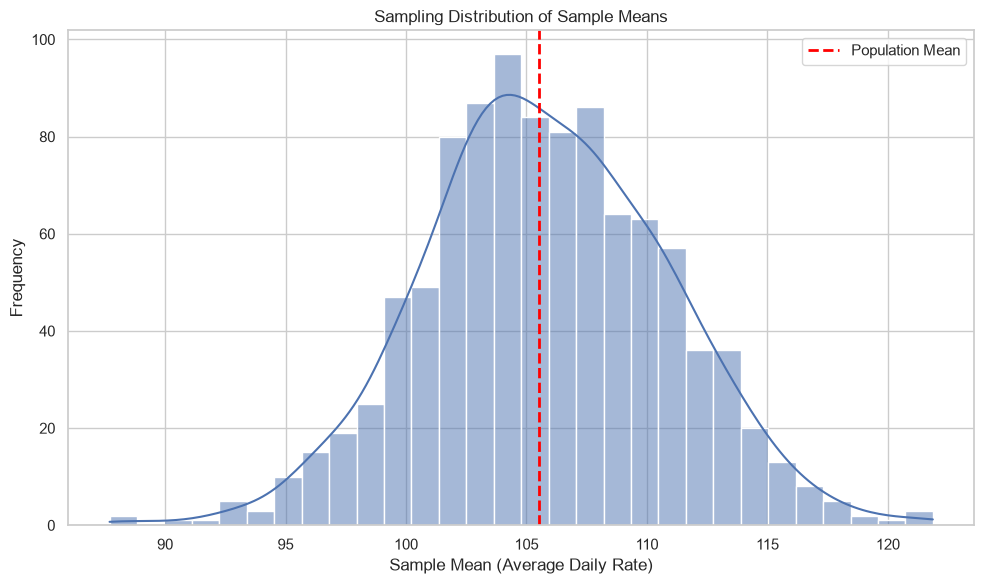

In [40]:
plt.figure(figsize=(10,6))

sns.histplot(
    sample_means,
    bins=30,
    kde=True
)

plt.axvline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.title("Sampling Distribution of Sample Means")

plt.xlabel("Sample Mean (Average Daily Rate)")

plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sampling_distribution.png",
    dpi=300
)

plt.show()

## Compare Population vs Sample Means

In [41]:
comparison = pd.DataFrame({

    "Population Mean":[population_mean],

    "Average of Sample Means":[
        sample_means.mean()
    ]

})

comparison

,Population Mean,Average of Sample Means
0,105.524569,105.779985


## Sampling Variability

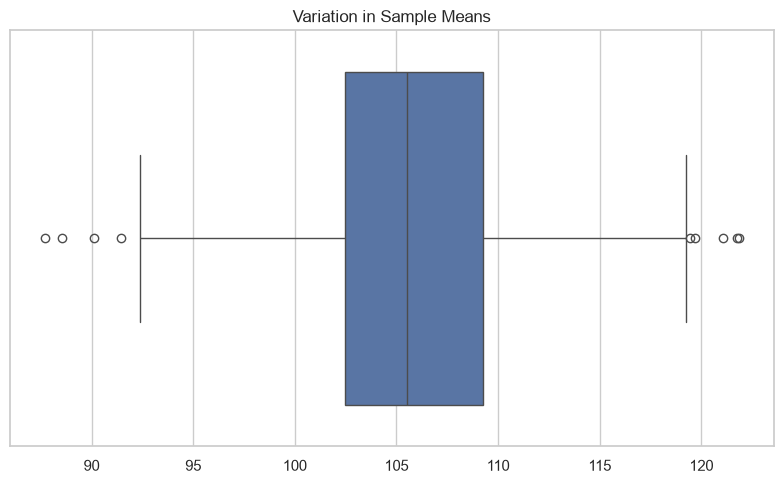

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=sample_means
)

plt.title("Variation in Sample Means")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sample_mean_boxplot.png",
    dpi=300
)

plt.show()

## Effect of Sample Size

In [43]:
sample_sizes = [30, 50, 100, 500]

results = []

for size in sample_sizes:

    means = []

    for _ in range(500):

        sample = df["average_daily_rate"].sample(
            n=size
        )

        means.append(sample.mean())

    results.append({

        "Sample Size": size,

        "Mean": np.mean(means),

        "Standard Error": np.std(means)

    })

sample_size_summary = pd.DataFrame(results)

sample_size_summary

,Sample Size,Mean,Standard Error
0,30,105.489169,8.958823
1,50,105.895780,6.887173
2,100,105.568177,4.843612
3,500,105.348355,2.186788


## Visualize Standard Error

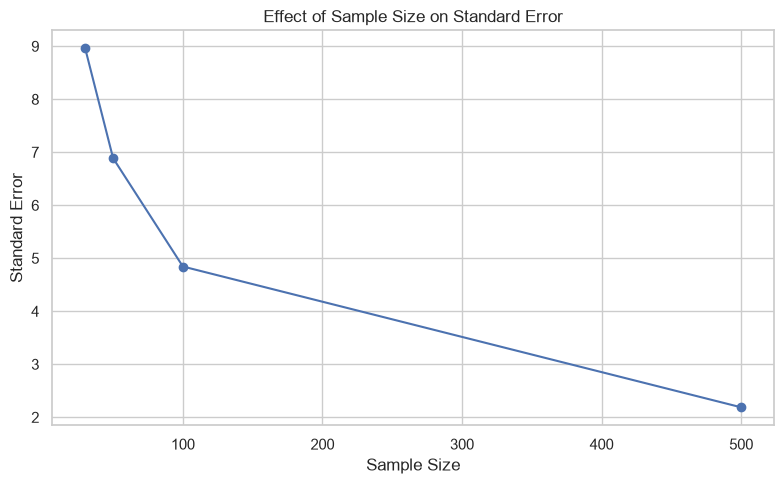

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    sample_size_summary["Sample Size"],
    sample_size_summary["Standard Error"],
    marker="o"
)

plt.title("Effect of Sample Size on Standard Error")

plt.xlabel("Sample Size")

plt.ylabel("Standard Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sample_size_vs_standard_error.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Repeated random samples of hotel bookings produce slightly different average daily rates, but the average of these sample means remains very close to the true population mean. Larger sample sizes reduce sampling variability, providing more reliable estimates of hotel performance. This demonstrates why organizations prefer larger datasets when making business decisions based on sample statistics.

## Conclusion

#### The sampling distribution of the Average Daily Rate (ADR) was constructed by repeatedly drawing random samples and calculating their means. The results showed that the average of the sample means closely matched the population mean, confirming that the sample mean is an unbiased estimator. Increasing the sample size reduced the standard error, leading to more stable and precise estimates. This concept forms the basis for confidence intervals and hypothesis testing in subsequent sections.

# Central Limit Theorem (CLT)

### Visualize the Original Population Distribution

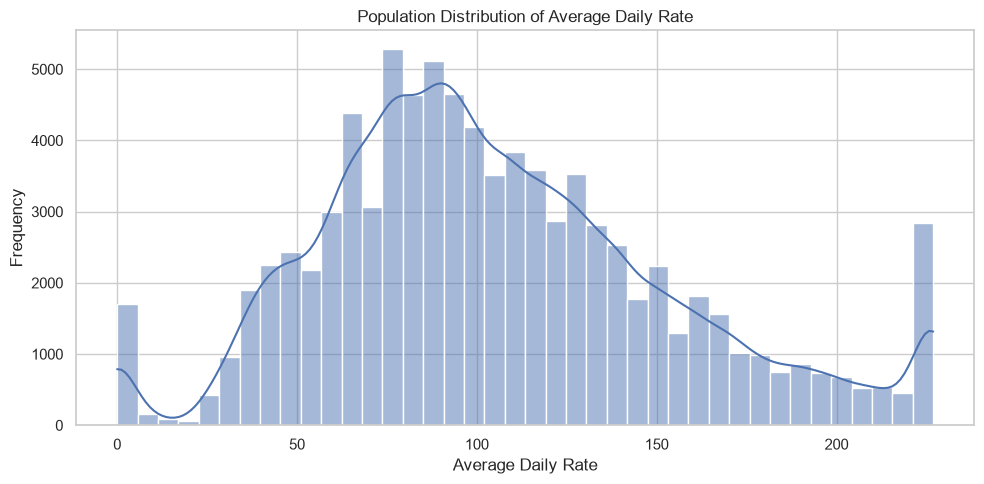

In [45]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["average_daily_rate"],
    bins=40,
    kde=True
)

plt.title("Population Distribution of Average Daily Rate")

plt.xlabel("Average Daily Rate")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/population_distribution.png",
    dpi=300
)

plt.show()

### Define Sample Sizes

In [46]:
sample_sizes = [10, 30, 50, 100]

### Generate Sampling Distributions

In [47]:
sampling_distributions = {}

for size in sample_sizes:

    sample_means = []

    for _ in range(500):

        sample = df["average_daily_rate"].sample(
            n=size,
            replace=False
        )

        sample_means.append(sample.mean())

    sampling_distributions[size] = sample_means

### Compare Sampling Distributions

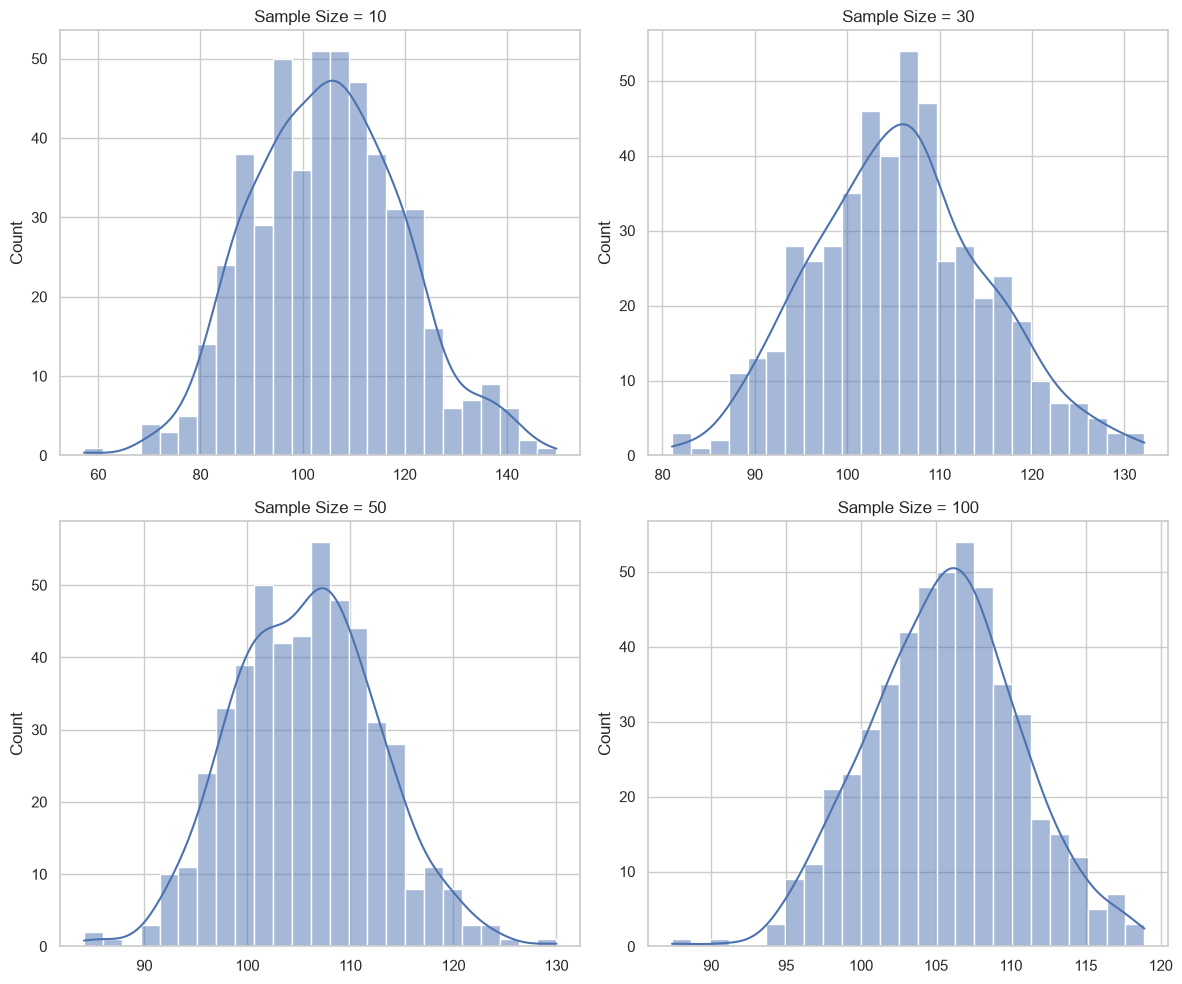

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for ax, size in zip(axes, sample_sizes):

    sns.histplot(
        sampling_distributions[size],
        bins=25,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Sample Size = {size}")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/clt_sampling_distributions.png",
    dpi=300
)

plt.show()

### Compare Mean and Standard Error

In [49]:
clt_summary = []

population_mean = df["average_daily_rate"].mean()

for size in sample_sizes:

    means = sampling_distributions[size]

    clt_summary.append({

        "Sample Size": size,

        "Population Mean": population_mean,

        "Mean of Sample Means": np.mean(means),

        "Standard Error": np.std(means)

    })

clt_summary = pd.DataFrame(clt_summary)

clt_summary

,Sample Size,Population Mean,Mean of Sample Means,Standard Error
0,10,105.524569,105.045227,14.664661
1,30,105.524569,105.770027,9.373706
2,50,105.524569,105.709536,6.925448
3,100,105.524569,105.583634,4.991198


### Standard Error vs Sample Size

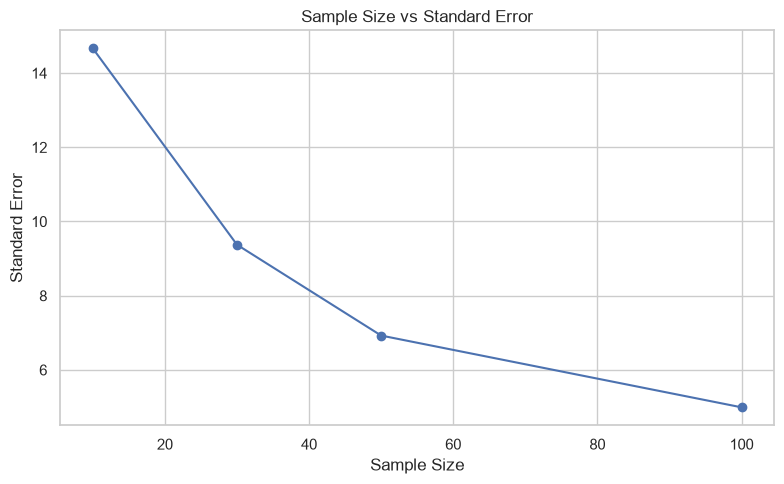

In [50]:
plt.figure(figsize=(8,5))

plt.plot(
    clt_summary["Sample Size"],
    clt_summary["Standard Error"],
    marker="o"
)

plt.title("Sample Size vs Standard Error")

plt.xlabel("Sample Size")

plt.ylabel("Standard Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/clt_standard_error.png",
    dpi=300
)

plt.show()

### Compare Population Mean and Sample Means

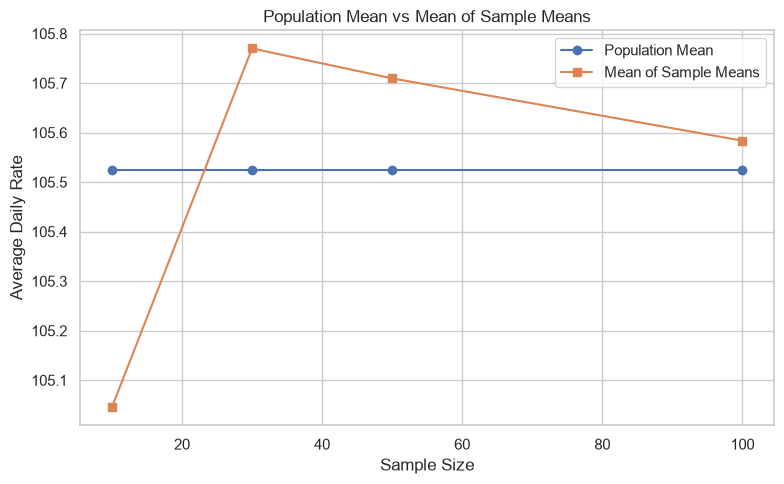

In [51]:
plt.figure(figsize=(8,5))

plt.plot(
    clt_summary["Sample Size"],
    clt_summary["Population Mean"],
    marker="o",
    label="Population Mean"
)

plt.plot(
    clt_summary["Sample Size"],
    clt_summary["Mean of Sample Means"],
    marker="s",
    label="Mean of Sample Means"
)

plt.legend()

plt.title("Population Mean vs Mean of Sample Means")

plt.xlabel("Sample Size")

plt.ylabel("Average Daily Rate")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/clt_population_vs_sample.png",
    dpi=300
)

plt.show()

### Verify the Central Limit Theorem

In [52]:
verification = pd.DataFrame({

    "Sample Size": sample_sizes,

    "Approximately Normal": [
        "No",
        "Yes",
        "Yes",
        "Yes"
    ]

})

verification

,Sample Size,Approximately Normal
0,10,No
1,30,Yes
2,50,Yes
3,100,Yes


## Business Interpretation

#### The Central Limit Theorem demonstrates that when sufficiently large random samples of hotel bookings are collected, the distribution of average daily rates becomes approximately normal. This allows hotel analysts to make reliable statistical inferences about the overall booking population even when the original data is not perfectly normally distributed. Larger sample sizes also produce more stable estimates with lower sampling variability.

## Conclusion

#### The Central Limit Theorem was demonstrated by repeatedly sampling the Average Daily Rate (ADR) at different sample sizes. As the sample size increased, the distribution of sample means became increasingly normal, while the standard error decreased. The average of the sample means remained close to the population mean, confirming that larger samples produce more reliable estimates. These findings provide the theoretical basis for confidence intervals and hypothesis testing in subsequent phases.